# Anomaly detection

Supervised classifiers are trained to recognise the fraud patterns present in the labelled training data. They cannot, by construction, recognise patterns the labels do not contain. Anomaly detection methods are designed for the opposite case: they learn what *legitimate* activity looks like and flag deviations, without using fraud labels at training time.

For a real risk scoring framework, both paradigms are useful. The supervised model captures known fraud efficiently; the anomaly detector raises the new and the unusual. We evaluate two methods here — Isolation Forest and an Autoencoder — using the test labels only for evaluation, never for training.


In [2]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
)
from tensorflow.keras import layers, models

PROCESSED_DIR = Path("..") / "data" / "processed"
MODELS_DIR = Path("..") / "src" / "models"
FIGURES_DIR = Path("..") / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")

In [3]:
train = pd.read_csv(PROCESSED_DIR / "train.csv")
test = pd.read_csv(PROCESSED_DIR / "test.csv")

X_train = train.drop(columns=["isFraud"])
y_train = train["isFraud"]
X_test = test.drop(columns=["isFraud"])
y_test = test["isFraud"]

print(f"Train: {X_train.shape}, fraud rate {y_train.mean():.4%}")
print(f"Test:  {X_test.shape}, fraud rate {y_test.mean():.4%}")

Train: (5090096, 11), fraud rate 0.1291%
Test:  (1272524, 11), fraud rate 0.1291%


## 1. Semi-supervised setup

Both methods are fit on the *legitimate-only* slice of the training data. This is closer to a realistic anomaly detection setup than fitting on a contaminated population: the model learns the shape of normal activity without being told that fraud exists, and is then asked to score everything in the test set. Fraud labels touch the pipeline only at evaluation time.


In [4]:
X_train_legit = X_train[y_train == 0]
print(f"Legitimate training rows: {len(X_train_legit):,}")

Legitimate training rows: 5,083,526


## 2. Isolation Forest

Isolation Forest works by recursively partitioning the feature space at random and measuring how few splits it takes to isolate each point. Anomalies are easy to isolate, they sit in low-density regions and get cut off quickly — while normal points need many splits.

The original sklearn defaults set `max_samples=256` because the algorithm's theoretical motivation rests on small subsamples per tree. With ~5M legitimate training rows this matters in practice: each tree sees a small, fast-to-process subsample and the ensemble averages over many trees.

`contamination="auto"` lets sklearn pick the threshold for `predict()`, but we don't actually use `predict()`. We use `decision_function()` to get a continuous anomaly score. This was the original notebook's main bug: computing PR-AUC on binary predictions destroys the ranking information that the metric is supposed to measure.


In [5]:
iso = IsolationForest(
    n_estimators=200,
    max_samples=256,
    contamination="auto",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
iso.fit(X_train_legit)

# decision_function returns the anomaly score: higher = more normal.
# We negate so higher = more anomalous, which matches the convention used by
# every other scoring function in the project and avoids sign confusion in
# the risk scoring notebook.
iso_scores = -iso.decision_function(X_test)

iso_pr_auc = average_precision_score(y_test, iso_scores)
iso_roc_auc = roc_auc_score(y_test, iso_scores)
print(f"Isolation Forest  PR-AUC = {iso_pr_auc:.4f}  ROC-AUC = {iso_roc_auc:.4f}")


Isolation Forest  PR-AUC = 0.0196  ROC-AUC = 0.9658


## One-Class SVM

One-Class SVM attempts to learn the boundary of normal behaviour and classifies points outside this boundary as anomalies.

It is more sensitive to scaling and high dimensionality compared to tree-based methods.

In [ ]:
from sklearn.svm import OneClassSVM

svm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.001
)

svm.fit(X_train)

In [ ]:
y_pred_svm = svm.predict(X_test)
y_pred_svm = (y_pred_svm == -1).astype(int)

## Local Outlier Factor

LOF measures the local density deviation of a given data point with respect to its neighbours.

Points with significantly lower density are considered anomalies.

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.001
)

y_pred_lof = lof.fit_predict(X_test)
y_pred_lof = (y_pred_lof == -1).astype(int)

## 3. Autoencoder

An autoencoder learns a compressed representation of legitimate transactions through a bottleneck layer and is evaluated by reconstruction error. Transactions that don't fit the learned manifold reconstruct poorly, so the per-row mean squared error is itself the anomaly score.

The architecture here is deliberately small (16 → 8 → 16, plus the input/output linear layer): the feature space has only 11 dimensions, and a deeper network would mostly memorise. The bottleneck of 8 is small enough to force genuine compression.

For a hard decision threshold (which we don't use here, since PR-AUC is computed on the continuous score), the threshold should be set on a held-out slice of legitimate training data, not on the test set. The original notebook computed it on the test MSE distribution, which is a form of leakage.


In [6]:
input_dim = X_train_legit.shape[1]

autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),     # bottleneck
    layers.Dense(16, activation="relu"),
    layers.Dense(input_dim, activation="linear"),
])
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           187 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 659 (2.57 KB)

 Trainable params: 659 (2.57 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# 10% of legitimate training rows are held out for validation. The
# validation MSE distribution would be the place to pick a hard threshold
# if one were needed.
history = autoencoder.fit(
    X_train_legit.values,
    X_train_legit.values,
    epochs=10,
    batch_size=512,
    validation_split=0.1,
    verbose=2,
)


Epoch 1/10
8936/8936 - 10s - 1ms/step - loss: 0.0275 - val_loss: 7.4959e-04
Epoch 2/10
8936/8936 - 8s - 885us/step - loss: 5.1211e-04 - val_loss: 3.5365e-04
Epoch 3/10
8936/8936 - 7s - 819us/step - loss: 3.2029e-04 - val_loss: 1.3449e-04
Epoch 4/10
8936/8936 - 8s - 872us/step - loss: 1.5040e-04 - val_loss: 7.4652e-05
Epoch 5/10
8936/8936 - 8s - 895us/step - loss: 1.0663e-04 - val_loss: 5.8458e-05
Epoch 6/10
8936/8936 - 10s - 1ms/step - loss: 9.9311e-05 - val_loss: 5.2268e-05
Epoch 7/10
8936/8936 - 7s - 809us/step - loss: 8.4373e-05 - val_loss: 4.9233e-05
Epoch 8/10
8936/8936 - 7s - 791us/step - loss: 8.5658e-05 - val_loss: 4.1032e-05
Epoch 9/10
8936/8936 - 7s - 835us/step - loss: 7.4269e-05 - val_loss: 4.4267e-05
Epoch 10/10
8936/8936 - 7s - 832us/step - loss: 6.9528e-05 - val_loss: 3.4164e-05


In [8]:
def reconstruction_error(model, X: pd.DataFrame) -> np.ndarray:
    """
    Return the per-row mean squared reconstruction error.

    Parameters
    ----------
    model : tf.keras.Model
        A trained autoencoder mapping ``X`` back to itself.
    X : pandas.DataFrame
        Input data. Converted to a NumPy array internally so subtraction is
        position-based and not subject to pandas index alignment.

    Returns
    -------
    numpy.ndarray
        One MSE value per row.
    """
    X_values = X.values
    reconstruction = model.predict(X_values, verbose=0)
    return np.mean((X_values - reconstruction) ** 2, axis=1)


In [9]:
ae_scores = reconstruction_error(autoencoder, X_test)
ae_pr_auc = average_precision_score(y_test, ae_scores)
ae_roc_auc = roc_auc_score(y_test, ae_scores)
print(f"Autoencoder       PR-AUC = {ae_pr_auc:.4f}  ROC-AUC = {ae_roc_auc:.4f}")

Autoencoder       PR-AUC = 0.1412  ROC-AUC = 0.9673


## 4. Comparison


In [10]:
results = pd.DataFrame([
    {"Model": "Isolation Forest", "PR-AUC": iso_pr_auc, "ROC-AUC": iso_roc_auc},
    {"Model": "Autoencoder",      "PR-AUC": ae_pr_auc,  "ROC-AUC": ae_roc_auc},
]).sort_values("PR-AUC", ascending=False).reset_index(drop=True)
results

,Model,PR-AUC,ROC-AUC
0,Autoencoder,0.141195,0.967343
1,Isolation Forest,0.019556,0.965823


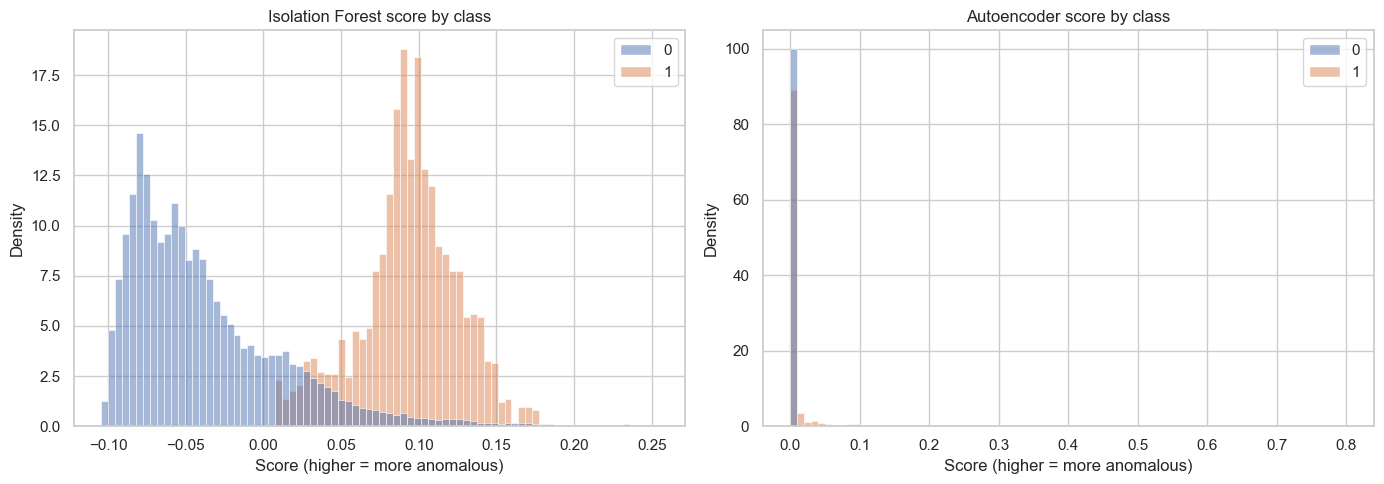

In [11]:
# Score distributions by class. A clean separation between the red and
# blue distributions corresponds to a useful detector; heavy overlap means
# the model is producing similar scores for fraud and legitimate activity.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, scores, name in zip(
    axes,
    [iso_scores, ae_scores],
    ["Isolation Forest", "Autoencoder"],
):
    sns.histplot(
        x=scores,
        hue=y_test.values,
        bins=80,
        stat="density",
        common_norm=False,
        alpha=0.5,
        ax=ax,
    )
    ax.set(title=f"{name} score by class",
           xlabel="Score (higher = more anomalous)",
           ylabel="Density")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "anomaly_score_distributions.png", dpi=150)
plt.show()


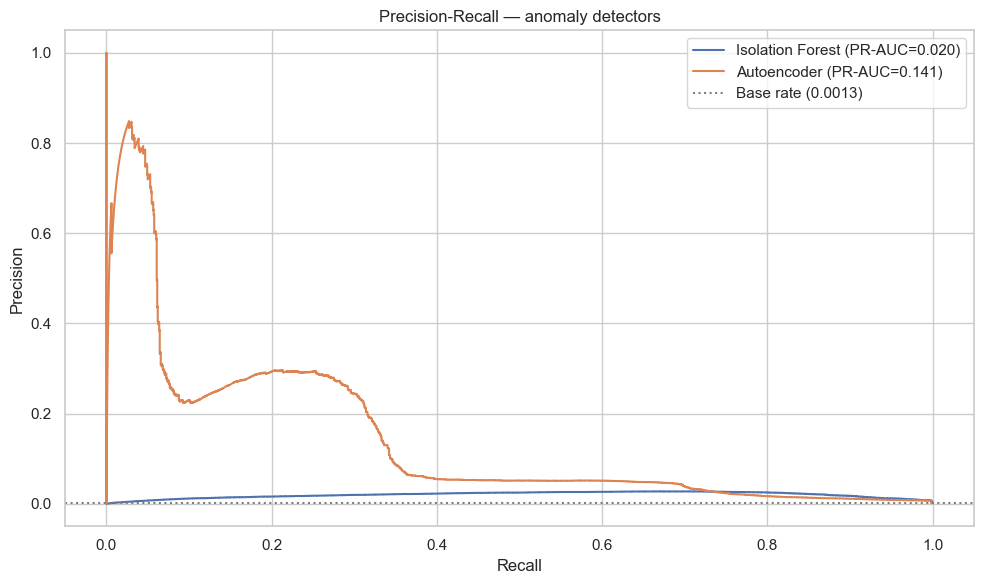

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
for scores, name in [
    (iso_scores, "Isolation Forest"),
    (ae_scores,  "Autoencoder"),
]:
    precision, recall, _ = precision_recall_curve(y_test, scores)
    pr_auc = average_precision_score(y_test, scores)
    ax.plot(recall, precision, label=f"{name} (PR-AUC={pr_auc:.3f})")
ax.axhline(y_test.mean(), linestyle=":", color="grey",
           label=f"Base rate ({y_test.mean():.4f})")
ax.set(title="Precision-Recall — anomaly detectors",
       xlabel="Recall", ylabel="Precision")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "anomaly_pr_curves.png", dpi=150)
plt.show()
